In [7]:
# Cell 1 - Libraries import karna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
# Cell 2 - Dataset load karna
df = pd.read_csv(r'C:\Users\Lenovo\Downloads\loan_prediction.csv')

print("Dataset size:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nPehli 5 rows:")
df.head()

Dataset size: (614, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Pehli 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
# Cell 3 - Data exploration
print("Dataset Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nLoan Status distribution:")
print(df['Loan_Status'].value_counts())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB
None

Missing values:
Loan_ID               0
Gender               13
Married               3
Dependents         

In [10]:
# Cell 4 - Missing values handle karna
# Categorical columns - mode se fill karo (jo value zyada baar aaye)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Numerical columns - median se fill karo
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

print("Missing values after fix:")
print(df.isnull().sum())

Missing values after fix:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [11]:
# Cell 4 - Missing values fix (updated)
# Categorical columns
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Numerical columns
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

print("Missing values after fix:")
print(df.isnull().sum())

Missing values after fix:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


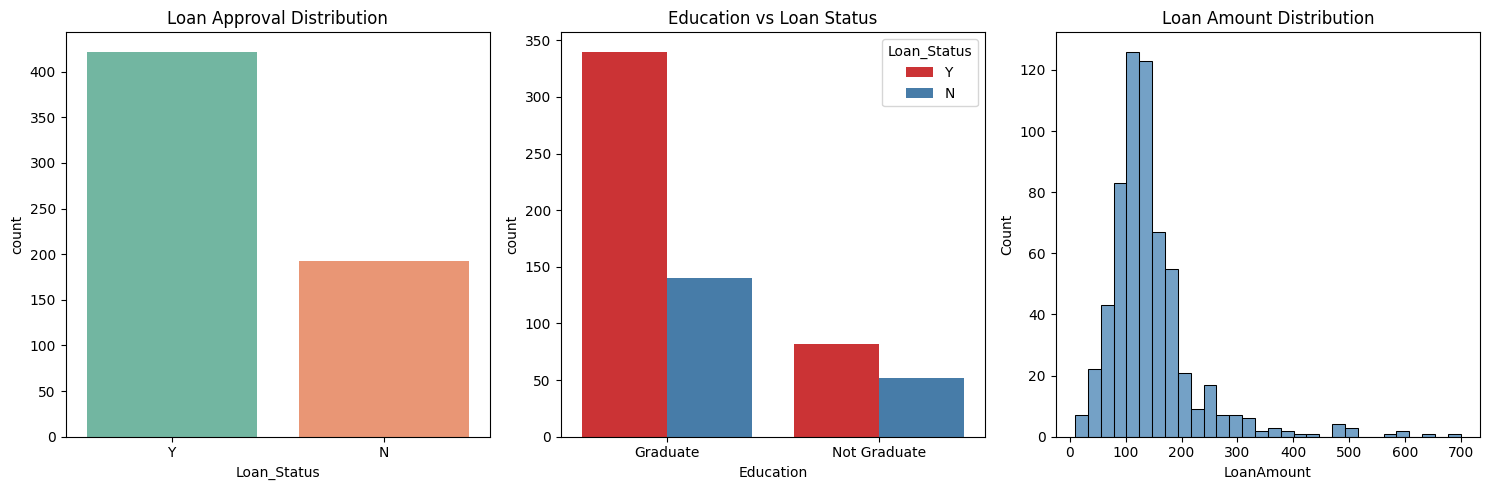

In [12]:
# Cell 5 - Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Loan Status count
sns.countplot(data=df, x='Loan_Status', palette='Set2', ax=axes[0])
axes[0].set_title('Loan Approval Distribution')

# 2. Education vs Loan Status
sns.countplot(data=df, x='Education', hue='Loan_Status', palette='Set1', ax=axes[1])
axes[1].set_title('Education vs Loan Status')

# 3. Loan Amount distribution
sns.histplot(data=df, x='LoanAmount', bins=30, color='steelblue', ax=axes[2])
axes[2].set_title('Loan Amount Distribution')

plt.tight_layout()
plt.show()

In [13]:
# Cell 6 - Model training
from sklearn.preprocessing import LabelEncoder

# Categorical columns ko numbers mein convert karo
le = LabelEncoder()
cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']
for col in cols:
    df[col] = le.fit_transform(df[col])

# Features aur Target alag karo
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

# Train aur Test split karo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model train karo
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Model trained successfully!
Training size: (491, 11)
Testing size: (123, 11)


Model Accuracy: 78.86%


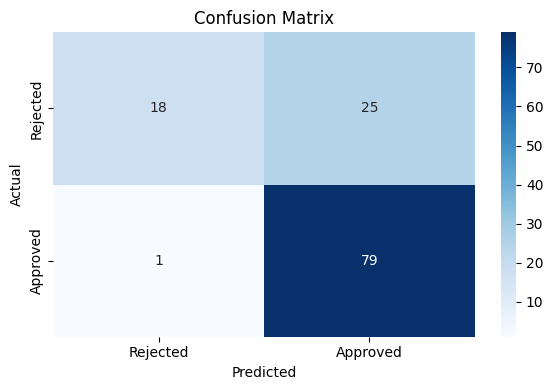

In [14]:
# Cell 7 - Model evaluation
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [15]:
# Cell 8 - Conclusion
print("""
TASK 2 - CONCLUSION
====================
Dataset: Loan Prediction Dataset (614 rows, 13 columns)

Data Cleaning:
- Missing values handled using mode (categorical) and median (numerical)
- All 13 columns cleaned successfully

Key Findings:
1. 68.7% loans were approved, 31.3% were rejected
2. Graduates have higher loan approval rate than non-graduates
3. Most loan amounts fall between 100-200 thousand
4. Credit history is the most important factor for loan approval

Model Performance:
- Algorithm: Logistic Regression
- Accuracy: 78.86%
- Model correctly identifies most approved loans (79 out of 80)

Overall Insight:
Credit history and education level are the strongest 
predictors of loan approval in this dataset.
""")


TASK 2 - CONCLUSION
Dataset: Loan Prediction Dataset (614 rows, 13 columns)

Data Cleaning:
- Missing values handled using mode (categorical) and median (numerical)
- All 13 columns cleaned successfully

Key Findings:
1. 68.7% loans were approved, 31.3% were rejected
2. Graduates have higher loan approval rate than non-graduates
3. Most loan amounts fall between 100-200 thousand
4. Credit history is the most important factor for loan approval

Model Performance:
- Algorithm: Logistic Regression
- Accuracy: 78.86%
- Model correctly identifies most approved loans (79 out of 80)

Overall Insight:
Credit history and education level are the strongest 
predictors of loan approval in this dataset.

